<h1 align="center"> 👴 Healthcare Premium Prediction — Older Population Model</h1>

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt
from sklearn.linear_model import LinearRegression,Lasso,Ridge
from sklearn.metrics import r2_score,mean_squared_error,mean_absolute_error
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split,cross_val_score,GridSearchCV,RandomizedSearchCV
from sklearn.preprocessing import MinMaxScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor
from xgboost import XGBRegressor

## Objective
To build and evaluate a machine learning model for individuals aged > 25 years 
to analyze how model performance differs in a more complex population segment.

This notebook aims to assess whether segmentation improves prediction accuracy 
for higher-risk individuals.

## Dataset Description
The young population model showed improved learning due to simpler patterns.

However, error analysis revealed that prediction issues were not fully resolved.

This notebook focuses on the older population (>25 years), 
which is expected to have:
- Higher premium variability
- More complex risk patterns

In [2]:
df=pd.read_excel("premiums_rest.xlsx")
df.head()

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount
0,26,Male,Northwest,Unmarried,0,Normal,No Smoking,Salaried,<10L,6,Diabetes,Bronze,9053
1,29,Female,Southeast,Married,2,Obesity,Regular,Salaried,<10L,6,Diabetes,Bronze,16339
2,49,Female,Northeast,Married,2,Normal,No Smoking,Self-Employed,10L - 25L,20,High blood pressure,Silver,18164
3,30,Female,Southeast,Married,3,Normal,No Smoking,Salaried,> 40L,77,No Disease,Gold,20303
4,56,Male,Northeast,Married,3,Obesity,Occasional,Self-Employed,10L - 25L,14,Diabetes,Bronze,15610


In [3]:
df.shape

(29904, 13)

In [4]:
df.columns

Index(['age', 'gender', 'region', 'marital_status', 'number_of_dependants',
       'bmi_category', 'smoking_status', 'employment_status', 'income_level',
       'income_lakhs', 'medical_history', 'insurance_plan',
       'annual_premium_amount'],
      dtype='object')

In [5]:
df.columns=df.columns.str.replace(" ","_").str.lower()

In [6]:
df.head()

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount
0,26,Male,Northwest,Unmarried,0,Normal,No Smoking,Salaried,<10L,6,Diabetes,Bronze,9053
1,29,Female,Southeast,Married,2,Obesity,Regular,Salaried,<10L,6,Diabetes,Bronze,16339
2,49,Female,Northeast,Married,2,Normal,No Smoking,Self-Employed,10L - 25L,20,High blood pressure,Silver,18164
3,30,Female,Southeast,Married,3,Normal,No Smoking,Salaried,> 40L,77,No Disease,Gold,20303
4,56,Male,Northeast,Married,3,Obesity,Occasional,Self-Employed,10L - 25L,14,Diabetes,Bronze,15610


<h2 align="center">🧹 Data Cleaning</h3>

### 1.Handling NA Values

In [7]:
df.isna().sum()

age                      0
gender                   0
region                   0
marital_status           0
number_of_dependants     0
bmi_category             0
smoking_status           9
employment_status        1
income_level             9
income_lakhs             0
medical_history          0
insurance_plan           0
annual_premium_amount    0
dtype: int64

if we consider the overall size of the dataset, these na values arent many. So the best thing to do is discard those rows. 

In [8]:
df.dropna(inplace=True)
df.isna().sum()

age                      0
gender                   0
region                   0
marital_status           0
number_of_dependants     0
bmi_category             0
smoking_status           0
employment_status        0
income_level             0
income_lakhs             0
medical_history          0
insurance_plan           0
annual_premium_amount    0
dtype: int64

### 2. Duplicate Records

In [9]:
df.duplicated().sum()

0

In [10]:
df.drop_duplicates(inplace=True)
df.duplicated().sum()

0

### 3. Invalid Values

In [11]:
df.describe()

,age,number_of_dependants,income_lakhs,annual_premium_amount
count,29886.000000,29886.000000,29886.000000,29886.000000
mean,43.396105,2.379910,23.364184,20892.303821
std,13.412657,1.431201,24.740339,6936.813440
min,26.000000,-3.000000,1.000000,3625.000000
25%,34.000000,1.000000,7.000000,15697.250000
50%,42.000000,3.000000,17.000000,20489.000000
75%,52.000000,3.000000,32.000000,26360.000000
max,356.000000,5.000000,930.000000,43471.000000


In [14]:
df[df.number_of_dependants<0]["number_of_dependants"].unique()

array([-1, -3], dtype=int64)

This would have occured probably because there was a bug in the data collection script. Instead of 1 and 3, it would have been saved -1 and -3.

In [15]:
df["number_of_dependants"]=abs(df["number_of_dependants"])
df["number_of_dependants"].describe()

count    29886.000000
mean         2.385933
std          1.421137
min          0.000000
25%          1.000000
50%          3.000000
75%          3.000000
max          5.000000
Name: number_of_dependants, dtype: float64

In [16]:
numeric_columns=df.select_dtypes(["float64","int64"]).columns
numeric_columns

Index(['age', 'number_of_dependants', 'income_lakhs', 'annual_premium_amount'], dtype='object')

### 📊 Outlier Treatment

##### age

In [18]:
df[df['age']>100]['age'].unique()

array([224, 124, 136, 203, 356], dtype=int64)

In [19]:
df1=df[df.age<=100].copy()
df1.describe()

,age,number_of_dependants,income_lakhs,annual_premium_amount
count,29828.000000,29828.000000,29828.000000,29828.000000
mean,43.095380,2.387790,23.371530,20901.900563
std,11.041991,1.420641,24.751262,6928.457636
min,26.000000,0.000000,1.000000,6538.000000
25%,34.000000,1.000000,7.000000,15706.000000
50%,42.000000,3.000000,17.000000,20496.000000
75%,52.000000,3.000000,32.000000,26361.000000
max,72.000000,5.000000,930.000000,43471.000000


##### Income

In [20]:
quantile_threshold=df1.income_lakhs.quantile(0.999)
quantile_threshold

100.0

In [21]:
df1[df1.income_lakhs>quantile_threshold].shape

(6, 13)

In [22]:
df2=df1[df1.income_lakhs<=quantile_threshold].copy()

In [23]:
df2.shape

(29822, 13)

### Numeric Columns Analysis

#### Univariate Analysis

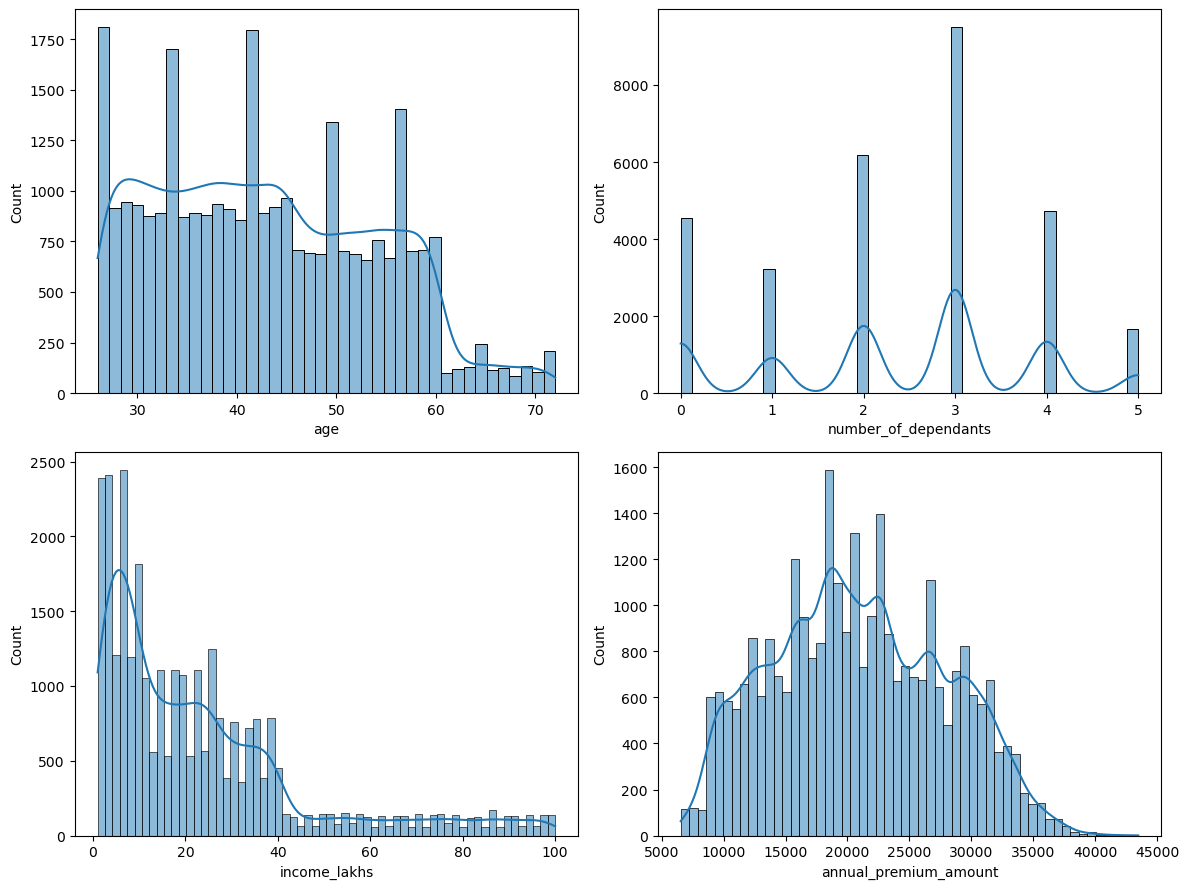

In [24]:
plt.figure(figsize=(12,9))
for i,col in enumerate(numeric_columns):
    plt.subplot(2,2,i+1)
    sns.histplot(x=df2[col],kde=True)
plt.tight_layout()
plt.show()

#### Bivariate Analysis

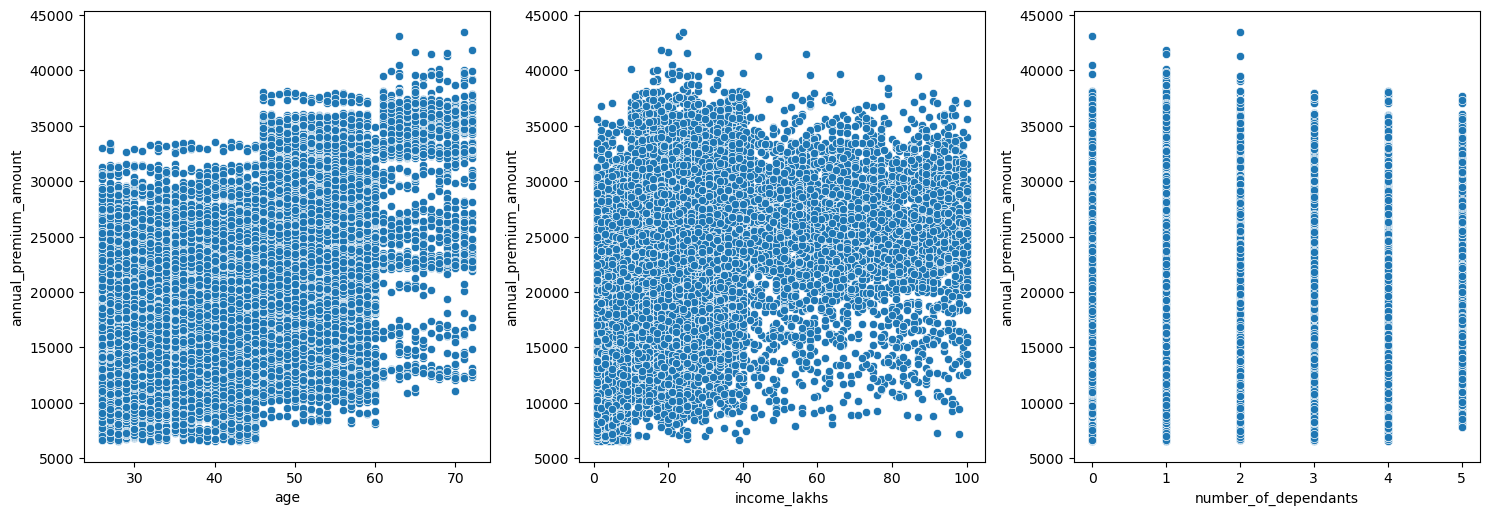

In [25]:
plt.figure(figsize=(15,15))
features = ["age", "income_lakhs", "number_of_dependants"]
for i,col in enumerate(features):
    plt.subplot(3,3,i+1)
    sns.scatterplot(df2,x=col,y="annual_premium_amount")
plt.tight_layout()
plt.show()

### Categorical Columns Analysis

In [26]:
categorical_col=df.select_dtypes(include=["object","category"]).columns
categorical_col

Index(['gender', 'region', 'marital_status', 'bmi_category', 'smoking_status',
       'employment_status', 'income_level', 'medical_history',
       'insurance_plan'],
      dtype='object')

In [27]:
for col in categorical_col:
    print(col,":", df2[col].unique())

gender : ['Male' 'Female']
region : ['Northwest' 'Southeast' 'Northeast' 'Southwest']
marital_status : ['Unmarried' 'Married']
bmi_category : ['Normal' 'Obesity' 'Overweight' 'Underweight']
smoking_status : ['No Smoking' 'Regular' 'Occasional' 'Does Not Smoke' 'Not Smoking'
 'Smoking=0']
employment_status : ['Salaried' 'Self-Employed' 'Freelancer']
income_level : ['<10L' '10L - 25L' '> 40L' '25L - 40L']
medical_history : ['Diabetes' 'High blood pressure' 'No Disease'
 'Diabetes & High blood pressure' 'Thyroid' 'Heart disease'
 'High blood pressure & Heart disease' 'Diabetes & Thyroid'
 'Diabetes & Heart disease']
insurance_plan : ['Bronze' 'Silver' 'Gold']


smoking_status : ['No Smoking' 'Smoking=0' 'Does Not Smoke' 'Not Smoking'] - here we can see an invalid category "Smoking=0". 

No Smoking, Smoking=0, Does Not Smoke, Not Smoking is all the same which is does not smoke.

In [28]:
df2["smoking_status"]=df2["smoking_status"].replace({
    'Smoking=0':"No Smoking",
    'Does Not Smoke':"No Smoking",
    'Not Smoking':'No Smoking'
})
df2.smoking_status.unique()

array(['No Smoking', 'Regular', 'Occasional'], dtype=object)

<h2 align="center">⚙️ Feature Engineering</h2>

In [29]:
df2.head(2)

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount
0,26,Male,Northwest,Unmarried,0,Normal,No Smoking,Salaried,<10L,6,Diabetes,Bronze,9053
1,29,Female,Southeast,Married,2,Obesity,Regular,Salaried,<10L,6,Diabetes,Bronze,16339


In [30]:
df2.medical_history.unique()

array(['Diabetes', 'High blood pressure', 'No Disease',
       'Diabetes & High blood pressure', 'Thyroid', 'Heart disease',
       'High blood pressure & Heart disease', 'Diabetes & Thyroid',
       'Diabetes & Heart disease'], dtype=object)

### Calculate Risk Score

In [31]:
risk_scores={
    "diabetes":6,
    "heart disease":8,
    "high blood pressure":6,
    "thyroid":5,
    "no disease":0,
    "none":0
}

df2[["disease 1","disease 2"]]=df2["medical_history"].str.split(" & ",expand=True).apply(lambda x: x.str.lower())
df2.head(5)

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,disease 1,disease 2
0,26,Male,Northwest,Unmarried,0,Normal,No Smoking,Salaried,<10L,6,Diabetes,Bronze,9053,diabetes,None
1,29,Female,Southeast,Married,2,Obesity,Regular,Salaried,<10L,6,Diabetes,Bronze,16339,diabetes,None
2,49,Female,Northeast,Married,2,Normal,No Smoking,Self-Employed,10L - 25L,20,High blood pressure,Silver,18164,high blood pressure,None
3,30,Female,Southeast,Married,3,Normal,No Smoking,Salaried,> 40L,77,No Disease,Gold,20303,no disease,None
4,56,Male,Northeast,Married,3,Obesity,Occasional,Self-Employed,10L - 25L,14,Diabetes,Bronze,15610,diabetes,None


In [32]:
df2["disease 1"]=df2["disease 1"].fillna("none")
df2["disease 2"]=df2["disease 2"].fillna("none")

#Create a new column for total risk
df2["total_risk_score"]=0

#Convert diseases to risk scores
for disease in ["disease 1","disease 2"]:
    df2["total_risk_score"]+=df2[disease].map(risk_scores)    


### Normalisng Risk Score 

In [33]:
max_score=df2["total_risk_score"].max()
min_score=df2["total_risk_score"].min()
df2["normalised_risk_score"]=(df2["total_risk_score"] - min_score) / (max_score - min_score)
df2.head(10)

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,disease 1,disease 2,total_risk_score,normalised_risk_score
0,26,Male,Northwest,Unmarried,0,Normal,No Smoking,Salaried,<10L,6,Diabetes,Bronze,9053,diabetes,none,6,0.428571
1,29,Female,Southeast,Married,2,Obesity,Regular,Salaried,<10L,6,Diabetes,Bronze,16339,diabetes,none,6,0.428571
2,49,Female,Northeast,Married,2,Normal,No Smoking,Self-Employed,10L - 25L,20,High blood pressure,Silver,18164,high blood pressure,none,6,0.428571
3,30,Female,Southeast,Married,3,Normal,No Smoking,Salaried,> 40L,77,No Disease,Gold,20303,no disease,none,0,0.000000
4,56,Male,Northeast,Married,3,Obesity,Occasional,Self-Employed,10L - 25L,14,Diabetes,Bronze,15610,diabetes,none,6,0.428571
5,33,Male,Southeast,Married,3,Normal,Regular,Self-Employed,<10L,4,Diabetes & High blood pressure,Silver,20653,diabetes,high blood pressure,12,0.857143
6,43,Male,Northeast,Married,3,Overweight,Regular,Salaried,> 40L,46,Thyroid,Gold,26926,thyroid,none,5,0.357143
7,59,Female,Southeast,Unmarried,0,Overweight,No Smoking,Freelancer,10L - 25L,21,No Disease,Gold,26101,no disease,none,0,0.000000
8,46,Female,Southeast,Married,4,Normal,Occasional,Self-Employed,10L - 25L,21,Thyroid,Gold,27176,thyroid,none,5,0.357143
9,68,Female,Southwest,Married,1,Normal,No Smoking,Self-Employed,<10L,1,Diabetes,Bronze,12596,diabetes,none,6,0.428571


### Ordinal encoding for ordered categories

#### Insurance Plan

In [34]:
df2["insurance_plan"]=df2["insurance_plan"].map({
    "Bronze":1,
    "Silver":2,
    "Gold":3
})

#### Income Level

In [35]:
df2.income_level.unique()

array(['<10L', '10L - 25L', '> 40L', '25L - 40L'], dtype=object)

In [36]:
df2["income_level"]=df2["income_level"].map({
    '<10L':1,
    "10L - 25L":2,
    "25L - 40L":3,
    "> 40L":4,
    
})

### One-hot encoding for nominal features

In [37]:
nominal_cols=["gender","region","marital_status","bmi_category","smoking_status","employment_status"]
df3=pd.get_dummies(df2,columns=nominal_cols,drop_first=True,dtype=int)
df3.head()

,age,number_of_dependants,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,disease 1,disease 2,total_risk_score,...,region_Southeast,region_Southwest,marital_status_Unmarried,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
0,26,0,1,6,Diabetes,1,9053,diabetes,none,6,...,0,0,1,0,0,0,0,0,1,0
1,29,2,1,6,Diabetes,1,16339,diabetes,none,6,...,1,0,0,1,0,0,0,1,1,0
2,49,2,2,20,High blood pressure,2,18164,high blood pressure,none,6,...,0,0,0,0,0,0,0,0,0,1
3,30,3,4,77,No Disease,3,20303,no disease,none,0,...,1,0,0,0,0,0,0,0,1,0
4,56,3,2,14,Diabetes,1,15610,diabetes,none,6,...,0,0,0,1,0,0,1,0,0,1


## Feature Selection

In [38]:
df4=df3.drop(columns=["medical_history","disease 1","disease 2","total_risk_score"])
df4

,age,number_of_dependants,income_level,income_lakhs,insurance_plan,annual_premium_amount,normalised_risk_score,gender_Male,region_Northwest,region_Southeast,region_Southwest,marital_status_Unmarried,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
0,26,0,1,6,1,9053,0.428571,1,1,0,0,1,0,0,0,0,0,1,0
1,29,2,1,6,1,16339,0.428571,0,0,1,0,0,1,0,0,0,1,1,0
2,49,2,2,20,2,18164,0.428571,0,0,0,0,0,0,0,0,0,0,0,1
3,30,3,4,77,3,20303,0.000000,0,0,1,0,0,0,0,0,0,0,1,0
4,56,3,2,14,1,15610,0.428571,1,0,0,0,0,1,0,0,1,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
29899,60,3,3,26,3,26370,0.428571,0,1,0,0,0,0,0,0,0,0,0,1
29900,40,0,2,16,3,29496,0.785714,0,0,1,0,1,0,1,0,0,1,1,0
29901,37,0,1,4,1,10957,0.000000,0,1,0,0,1,1,0,0,0,0,1,0
29902,47,2,4,82,3,27076,0.357143,0,0,1,0,0,0,0,0,0,0,1,0


## 📊 Correlation Analysis

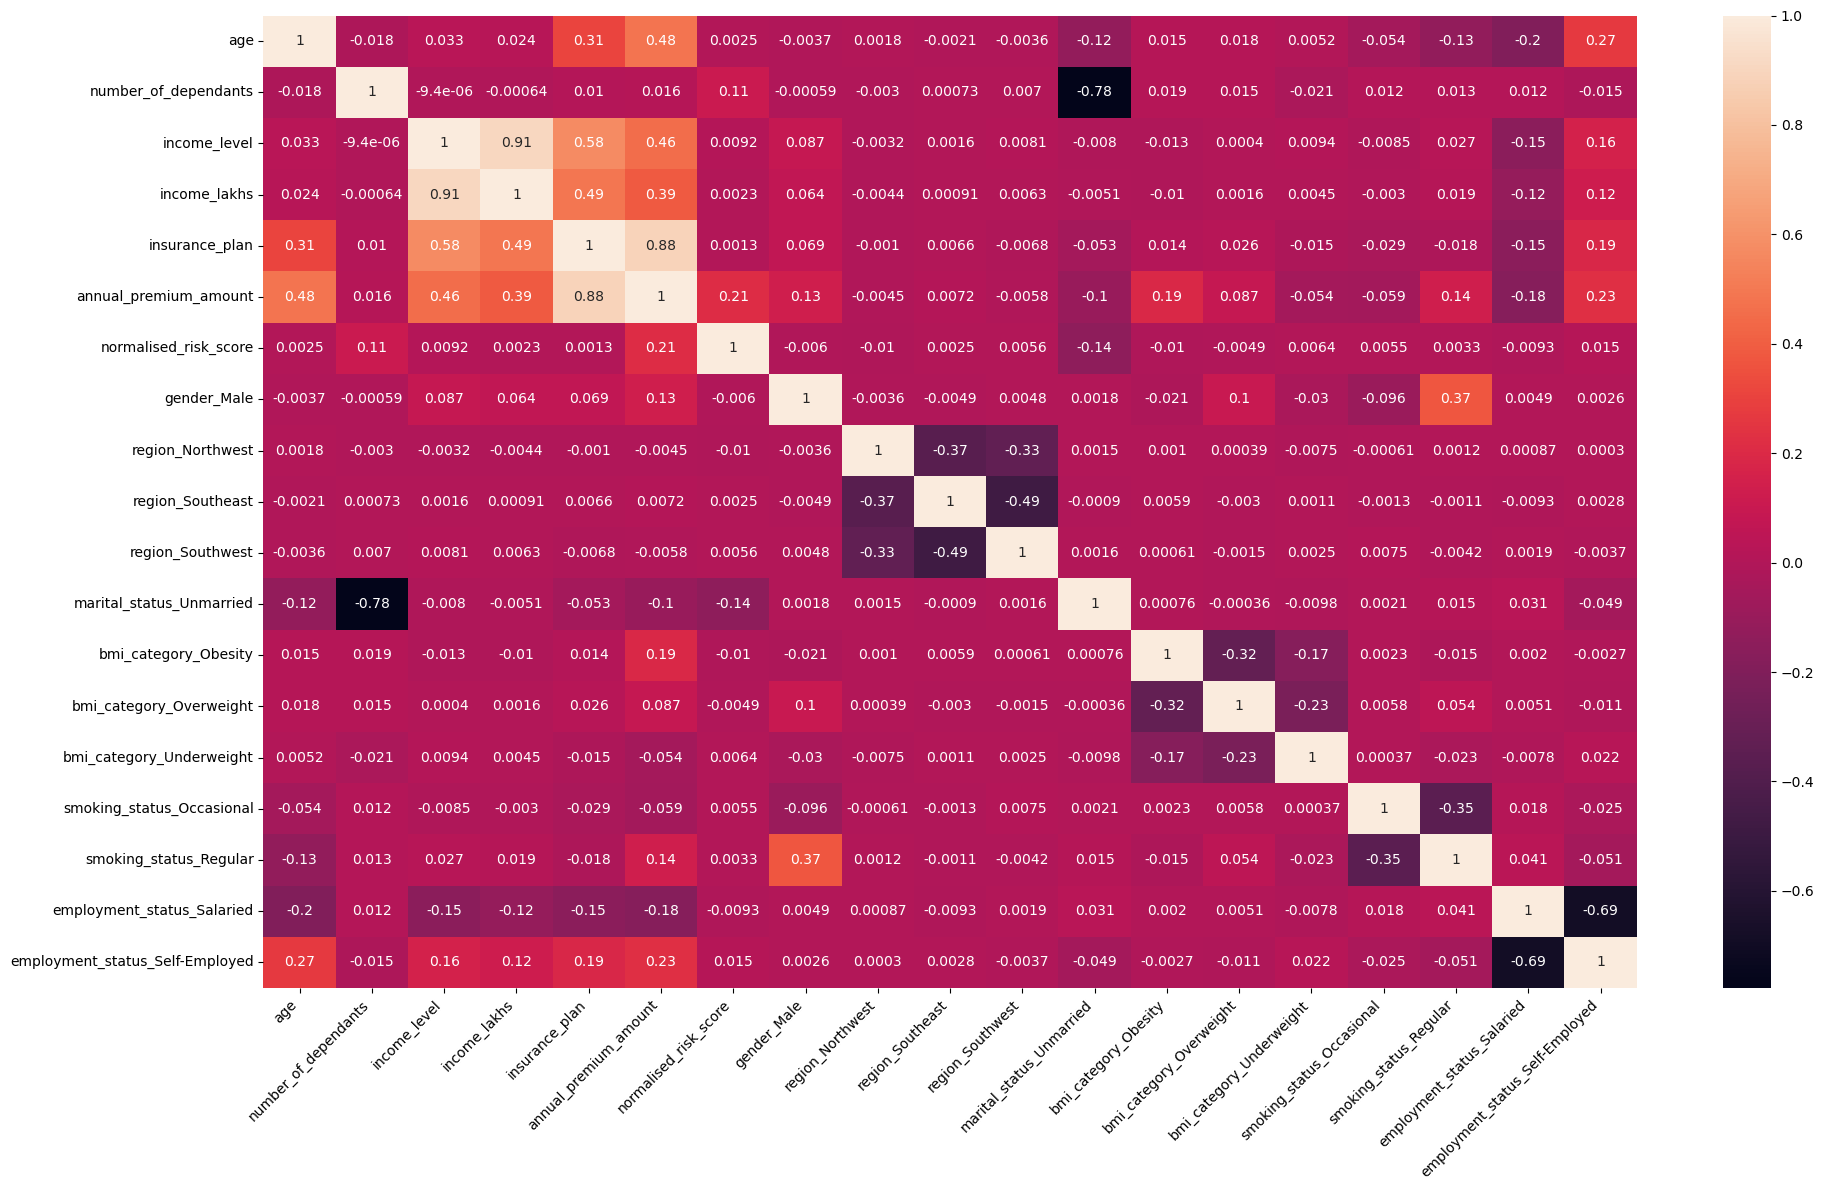

In [39]:
cm=df4.corr()

plt.figure(figsize=(20,12))
sns.heatmap(cm,annot=True)
plt.xticks(rotation=45,ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## Scaling Numerical Columns

In [40]:
X=df4.drop("annual_premium_amount",axis=1)
y=df4["annual_premium_amount"]

cols_to_scale=["age","number_of_dependants","income_lakhs","income_level","insurance_plan"]
scaler=MinMaxScaler()

X[cols_to_scale]=scaler.fit_transform(X[cols_to_scale])
X.head()

,age,number_of_dependants,income_level,income_lakhs,insurance_plan,normalised_risk_score,gender_Male,region_Northwest,region_Southeast,region_Southwest,marital_status_Unmarried,bmi_category_Obesity,bmi_category_Overweight,bmi_category_Underweight,smoking_status_Occasional,smoking_status_Regular,employment_status_Salaried,employment_status_Self-Employed
0,0.000000,0.0,0.000000,0.050505,0.0,0.428571,1,1,0,0,1,0,0,0,0,0,1,0
1,0.065217,0.4,0.000000,0.050505,0.0,0.428571,0,0,1,0,0,1,0,0,0,1,1,0
2,0.500000,0.4,0.333333,0.191919,0.5,0.428571,0,0,0,0,0,0,0,0,0,0,0,1
3,0.086957,0.6,1.000000,0.767677,1.0,0.000000,0,0,1,0,0,0,0,0,0,0,1,0
4,0.652174,0.6,0.333333,0.131313,0.0,0.428571,1,0,0,0,0,1,0,0,1,0,0,1


### Feature Selection using VIF

VIF (Variance Inflation Factor) is used to detect multicollinearity.

Even within this segment, feature relationships may differ, 
so VIF is applied again to ensure model stability.

In [41]:
def calculate_vif(data):
    vif_df=pd.DataFrame()
    vif_df["Columns"]=data.columns
    vif_df["VIF"]=[variance_inflation_factor(data.values,i) for i in range(data.shape[1])]
    return vif_df

In [42]:
calculate_vif(X)

,Columns,VIF
0,age,3.921783
1,number_of_dependants,6.278938
2,income_level,13.890522
3,income_lakhs,11.185596
4,insurance_plan,5.271297
5,normalised_risk_score,3.810619
6,gender_Male,2.599098
7,region_Northwest,2.123965
8,region_Southeast,2.980842
9,region_Southwest,2.710097


In [43]:
calculate_vif(X.drop("income_level",axis=1))

,Columns,VIF
0,age,3.863055
1,number_of_dependants,6.278147
2,income_lakhs,2.678102
3,insurance_plan,4.574625
4,normalised_risk_score,3.808345
5,gender_Male,2.591439
6,region_Northwest,2.123277
7,region_Southeast,2.979899
8,region_Southwest,2.708641
9,marital_status_Unmarried,2.345757


Now VIF is less than 10 for all columns

In [44]:
X_reduced=X.drop("income_level",axis=1)


<h2 align="center"> Model Training</h2>

Models are trained on the older population dataset to evaluate performance 
in a more complex and heterogeneous group.

In [45]:
X_train,x_test,y_train,y_test=train_test_split(X_reduced,y,test_size=0.3,random_state=10)

In [46]:
X_train.shape

(20875, 17)

In [47]:
x_test.shape

(8947, 17)

### Linear Regression

In [48]:
model_lr=LinearRegression()
model_lr.fit(X_train,y_train)
train_score=model_lr.score(X_train,y_train)
test_score=model_lr.score(x_test,y_test)
train_score,test_score

(0.9534163989489616, 0.9538448451629948)

In [49]:
np.set_printoptions(suppress=True, precision=6)
model_lr.coef_

array([ 7016.239328, -1311.764702,  -708.193369, 14835.988208,
        6053.624123,    37.558269,   -55.250872,   -19.622543,
         -22.289676,  -700.3202  ,  3926.812706,  1979.456047,
         612.866236,   837.395101,  2800.661843,   -45.491367,
         243.078421])

In [50]:
feature_importances=model_lr.coef_

In [51]:
coef_df=pd.DataFrame(feature_importances,index=x_test.columns,columns=["Coefficients"])
coef_df=coef_df.sort_values(by="Coefficients",ascending=True)
coef_df

,Coefficients
number_of_dependants,-1311.764702
income_lakhs,-708.193369
marital_status_Unmarried,-700.320200
region_Northwest,-55.250872
employment_status_Salaried,-45.491367
region_Southwest,-22.289676
region_Southeast,-19.622543
gender_Male,37.558269
employment_status_Self-Employed,243.078421
bmi_category_Underweight,612.866236


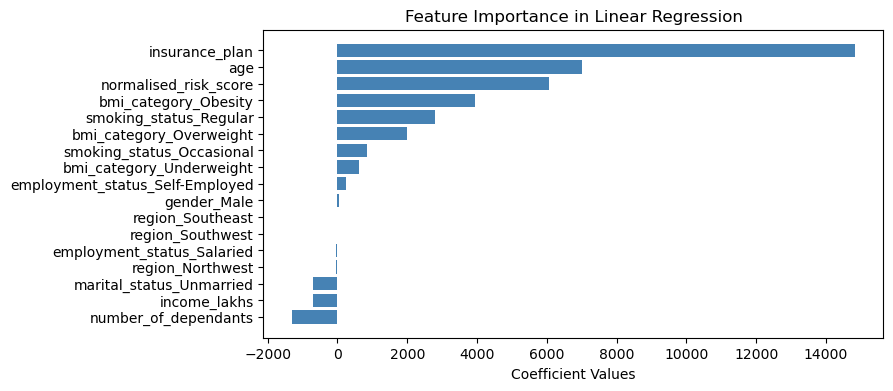

In [52]:
plt.figure(figsize=(8,4))
plt.barh(coef_df.index,coef_df["Coefficients"],color="steelblue")
plt.xlabel("Coefficient Values")
plt.title("Feature Importance in Linear Regression")
plt.show()

### Ridge Regression 

In [54]:
model_rg = Ridge(alpha=1)
model_rg.fit(X_train, y_train)
test_score = model_rg.score(x_test, y_test)
train_score = model_rg.score(X_train, y_train)
train_score, test_score

(0.9534162332209687, 0.9538456995663842)

### XGBoost

In [55]:
model_xgb=XGBRegressor()
model_xgb.fit(X_train,y_train)
model_xgb.score(x_test,y_test)

0.9979538321495056

with xgboost we got accuracy of 99%

### Random Search CV

In [56]:
model_xgb=XGBRegressor()

param_grid={
    'n_estimators':[20,40,50],
    'learning_rate':[0.01,0.1,0.2],
    'max_depth':[3,4,5]
}

random_search=RandomizedSearchCV(model_xgb,param_grid,n_iter=10,cv=3,scoring='r2',random_state=42,n_jobs=-1)
random_search.fit(X_train,y_train)
random_search.best_score_

0.9970577955245972

In [57]:
random_search.best_params_

{'n_estimators': 50, 'max_depth': 5, 'learning_rate': 0.1}

<h2> Model Evaluation</h2>

| Model                |R2|
|:---------------------|:----:|
|Linear               |0.95|
|Ridge Regression      |0.95|
|XGBoost              |0.99|
|XGBoost Tuned |0.99|

### Insight

- All models show high performance (R² ≥ 0.95), indicating that a large portion of the variance in premiums is explained for this segment
- XGBoost (both base and tuned) slightly outperforms linear models (R² ≈ 0.99), suggesting the presence of non-linear relationships in the data
- The strong performance across all models indicates that the available features capture the underlying patterns effectively for this group
- Minimal difference between tuned and untuned XGBoost suggests that the model is already well-suited to the data


<h1 align="center"> Error Analysis</h1>

In [58]:
best_model = random_search.best_estimator_

In [59]:
y_pred=best_model.predict(x_test)

residuals=y_pred-y_test
residuals_pct=residuals*100/y_test

results_df=pd.DataFrame({
    'actual':y_test,
    'predicted':y_pred,
    'diff':residuals,
    'diff_pct':residuals_pct
})

results_df.head()

,actual,predicted,diff,diff_pct
19713,26895,26691.470703,-203.529297,-0.756755
14750,22734,22650.751953,-83.248047,-0.366183
19932,21198,21581.894531,383.894531,1.810994
29643,9100,9425.934570,325.934570,3.581699
17076,26434,26691.470703,257.470703,0.974013


<Axes: xlabel='diff_pct', ylabel='Count'>

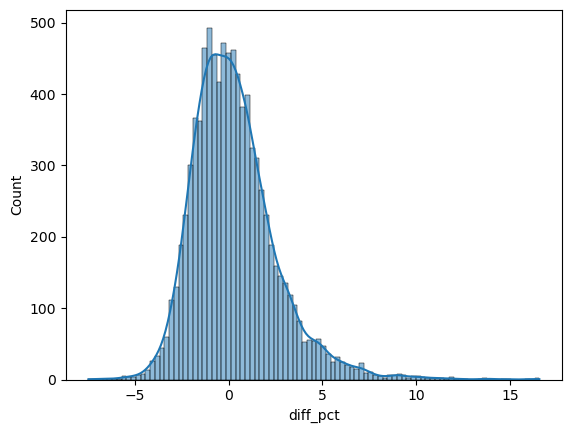

In [60]:
sns.histplot(results_df["diff_pct"],kde=True)

### Error Distribution Insight

- The error distribution is centered around zero, indicating unbiased predictions
- Most prediction errors lie within a narrow range (-5% to +5%)
- Extreme errors are minimal (~0.3%), showing high prediction stability

This suggests that the model is able to consistently capture the underlying patterns in this segment.

In [61]:
extreme_error_threshold=10
extreme_results_df=results_df[np.abs(results_df["diff_pct"])>extreme_error_threshold]
extreme_results_df.shape

(29, 4)

In [62]:
(extreme_results_df.shape[0]*100)/results_df.shape[0]

0.32413099362914943

We have very few extreme errors (only 0.3%) which means this model looks good and no further investigation is required

## Comparison with Young Population

| Metric | Young | Older |
|:--------|:------:|:-------:|
| R2 Score | 0.60 | 0.99 |
|Extreme Error % (>10%)|73%|0.3%|
|Error Distribution|Skewed, wide spread |Centered, narrow spread|


- Young group:
  - High extreme error rates
  - Skewed error distribution

- Older group:
  - Stable error distribution
  - Minimal extreme errors

This indicates that model behavior differs significantly across segments.

## Conclusion

The model for the rest of the population demonstrates more stable prediction behavior, 
with no extreme errors observed.

However:
- Stability does not necessarily imply higher accuracy
- Errors may still exist but are more evenly distributed

This highlights that segmentation reveals different error characteristics across groups.